# Scaling laws: build the best associative memory you can

In [1]:
# Colab setup -- a no-op anywhere else.
USE_DRIVE = False   # True: keep your lab state in Google Drive

import importlib
import os
import subprocess
import sys
import math

if "google.colab" in sys.modules:
    PKG = "git+https://github.com/NicolasZucchet/Tutorial-scaling-laws"
    # installed straight from git, not cloned: nothing to keep in sync by hand, and a
    # plain (non-editable) install is importable in this already-running kernel, which an
    # editable one is not.  --no-deps leaves Colab's own jax, numpy, scipy and matplotlib
    # alone -- resolving them again would swap the CUDA jax for the CPU wheel.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
    subprocess.run([sys.executable, "-m", "uv", "pip", "install", "-q", "--system",
                    "--python", sys.executable, "--no-deps", PKG], check=True)
    importlib.invalidate_caches()
    base = "/content/assocmem"
    if USE_DRIVE:
        from google.colab import drive

        drive.mount("/content/drive")
        base = "/content/drive/MyDrive/assocmem"
    # site-packages has no project root to hang these off, so say where they go
    os.environ["ASSOCMEM_CACHE"] = f"{base}/cache"
    os.environ["ASSOCMEM_RUNS"] = f"{base}/runs"
    import jax

    # float32 matmuls, not TF32 -- so the losses match the reference numbers on any GPU
    jax.config.update("jax_default_matmul_precision", "highest")
    print(f"jax {jax.__version__} on {jax.default_backend()}; ready.", flush=True)
else:
    # Locally, `uv sync` (or `pip install -e .`) is the supported route and this branch is
    # a no-op.  A checkout opened straight in Jupyter is the case it covers: nothing is
    # installed, and the notebook's cwd is notebooks/, so walk up to the repo root and put
    # its src/ on the path.  Runs and caches then land in the checkout's own runs/ and
    # results/cache/, which is why the Colab branch above has to name them and this one
    # does not.
    from pathlib import Path

    try:
        import assocmem  # noqa: F401  -- already installed, nothing to do
    except ModuleNotFoundError:
        for root in (Path.cwd(), *Path.cwd().parents):
            if (root / "src" / "assocmem" / "__init__.py").exists():
                sys.path.insert(0, str(root / "src"))
                break
        else:
            raise ModuleNotFoundError(
                f"assocmem is not installed and no checkout was found above {Path.cwd()}."
                " Run `uv sync` in the repo, or start Jupyter from inside it."
            ) from None
    import jax

    print(f"jax {jax.__version__} on {jax.default_backend()}; ready.", flush=True)


jax 0.11.0 on cpu; ready.


In [ ]:
%config InlineBackend.figure_formats = ['retina']
from assocmem import (Lab, Sweep, BudgetError, plot_runs, plot_summary, powerlaw,
                      saturating_powerlaw, joint_fit, isoflop_optimum, r2_of)

## Part 1: demo on the same toy model as in the tutorial

**WARNING.** The real task (Part 2) is different, so not all findings here extend to the other model.

In [3]:
demo = Lab("demo", budget=2e14, rounds=6, deterministic=True)

lab 'demo' [one correct answer]:  1.581e+13 / 2e+14 flops spent (7.9%),  1.842e+14 left  |  rounds 6/6  |  206 runs recorded


### 1. The learning rate, per model size

Before any scaling law: at one compute budget, sweep the learning rate across model sizes. Every
IsoFLOP point below is only as good as its learning rate, and the Chinchilla runs were tuned per
model size for exactly this reason.

`Sweep` is a cartesian product. Give any **two** of `c` (flops per run), `n` (parameters) and
`d` (tokens per run) and the third follows from $C=6ND$.

`sweep.estimate(lab)` is free; `lab.run_round` spends one round however many configs it holds.
There is no dry-run mode, because a malformed sweep raises when you build it and an
unaffordable one is refused before anything trains.

In [4]:
lr = Lab("lr", budget=2e14, rounds=3, deterministic=True)
s_lr = Sweep(
    c=[1e10],
    n=[2**(12 + i) for i in range(5)],
    lr=[0.001, 0.01, 0.1, 1]
)        

s_lr.estimate(lr);

lab 'lr' [one correct answer]:  0 / 2e+14 flops spent (0.0%),  2e+14 left  |  rounds 0/3  |  0 runs recorded
20 runs in 5 groups  ->  2.04e+11 flops, ~3 s
  0.1% of the 2e+14 budget; 2e+14 left (3 rounds)
  FITS


In [5]:
r_lr = lr.run_round("lr landscape", s_lr, plot=False)

round 'lr landscape': 20 runs in 5 groups, 2.04e+11 flops, ~3 s
  [1/5] N=   65,536 D=   25,408  best lr=0.1 loss=1.6627
  [2/5] N=   16,384 D=  101,696  best lr=0.1 loss=1.9260
  [3/5] N=    4,096 D=  406,912  best lr=0.01 loss=2.7685
  [4/5] N=    8,192 D=  203,456  best lr=0.1 loss=2.2585
  [5/5] N=   32,768 D=   50,880  best lr=0.1 loss=1.7572

best this round: N=65,536 D=25,408 lr=0.1  ->  loss 1.6627   (7 s)
lab 'lr' [one correct answer]:  2.041e+11 / 2e+14 flops spent (0.1%),  1.998e+14 left  |  rounds 1/3  |  20 runs recorded


In [ ]:
plot_runs(r_lr, x="lr", y="loss", color="n", reduce=None,
          title="loss vs learning rate, by model size")

for o in r_lr.lr_optima():
    print(f"N={o['n']:9,}  lr*={o['lr_star']:.4f}  best={o['lr_best']:.4f}  {o['where']}")

# color=None puts every run in one series, which is what you want once the question is
# about the envelope rather than about one size: the best loss reached at each lr.
plot_runs(r_lr, x="lr", y="loss", color=None, title="best loss at each lr, over all sizes");

### 2. Different fitting strategies

In the tutorial, we saw 3 different ways to estimate what $N^*$ should be as a function of $C$; we show examples on how to do that with the current code base.

#### Pareto front (for each model size, loss against compute, read n* off the envelope)

lab 'pareto' [one correct answer]:  1.138e+12 / 2e+14 flops spent (0.6%),  1.989e+14 left  |  rounds 1/3  |  210 runs recorded
210 runs in 70 groups  ->  1.14e+12 flops, ~38 s
  0.6% of the 2e+14 budget; 1.99e+14 left (2 rounds)
  FITS
  by C rung: 2.56e+10: 5.44e+11 (21 runs),  1.28e+10: 2.75e+11 (21 runs),  6.4e+09: 1.41e+11 (21 runs),  3.2e+09: 7.36e+10 (21 runs),  1.6e+09: 4e+10 (21 runs),  8e+08: 2.32e+10 (21 runs),  4e+08: 1.48e+10 (21 runs),  2e+08: 1.06e+10 (21 runs),  1e+08: 8.5e+09 (21 runs),  5e+07: 7.45e+09 (21 runs)
---
all 210 configs already run -- served from cache, no flops and no round spent.

Pareto      n* = 0.163 C^0.576   r2=0.9733
            touching points: [('5.0e+07', '4,096'), ('1.0e+08', '8,192'), ('2.0e+08', '8,192'), ('4.0e+08', '16,384'), ('8.0e+08', '16,384'), ('1.6e+09', '32,768'), ('3.2e+09', '65,536'), ('6.4e+09', '65,536'), ('1.3e+10', '131,072'), ('2.6e+10', '131,072')]
10
10
10
10
10
10
10


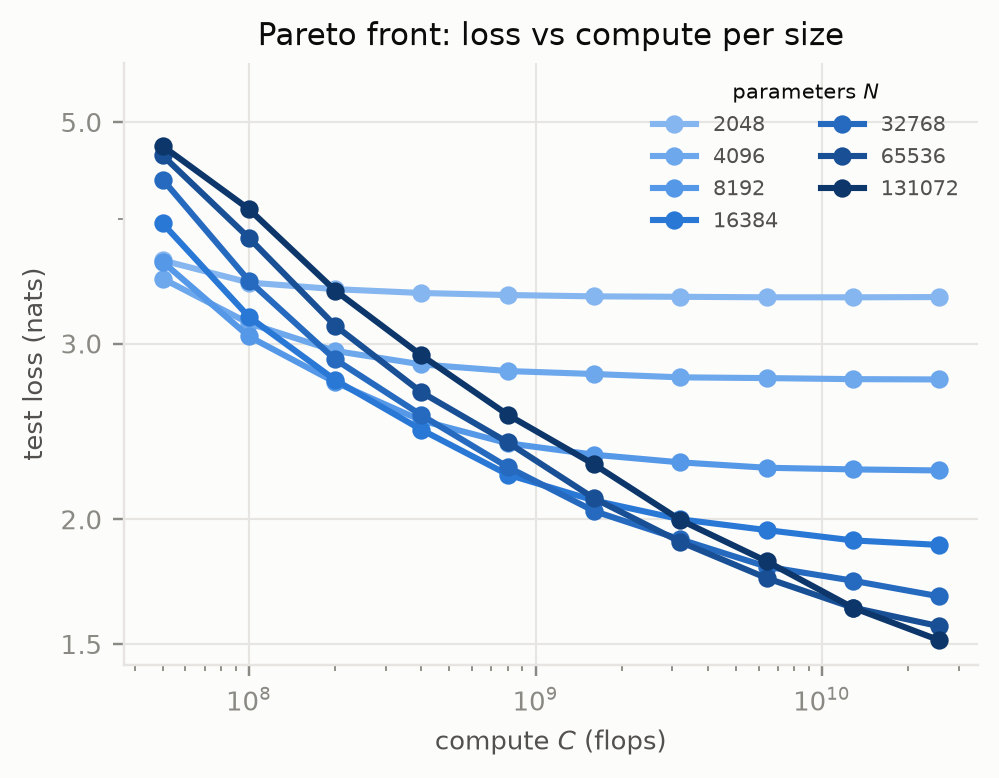

3
7


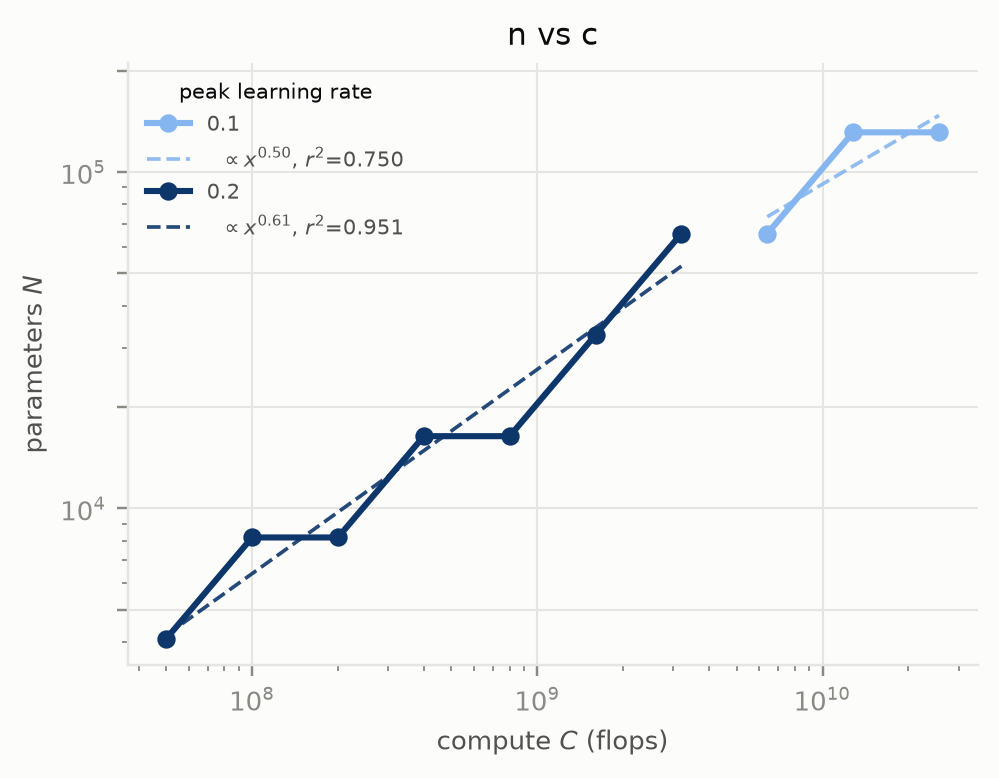

In [7]:
pareto = Lab("pareto", budget=2e14, rounds=3, deterministic=True)
s_pareto = Sweep(c=[0.5e8 * 2**i for i in range(10)],
                 n=[2**(11 + i) for i in range(7)],
                 lr=[0.05, 0.1, 0.2])
s_pareto.estimate(pareto)
print('---')

r_pareto = pareto.run_round("pareto", s_pareto, plot=False)

pareto = [r_pareto.best(c=c) for c in r_pareto.rungs]  # picks the best run per compute range (i.e. enveloppe)
a, b_par, r2 = powerlaw([p["c"] for p in pareto], [p["n"] for p in pareto]) # power law fit
print(f"\nPareto      n* = {a:.3g} C^{b_par:.3f}   r2={r2:.4f}")
print("            touching points:", [(f"{p['c']:.1e}", f"{p['n']:,}") for p in pareto])

plot_runs(r_pareto, x="c", y="loss", color="n",
          title="Pareto front: loss vs compute per size");

plot_runs(pareto, x="c", y="n", color="lr", fit="powerlaw");

#### IsoFLOP curves (at fixed compute, sweep the size, fit parabola in log size)

In [ ]:
isoflop = Lab("isoflop", budget=2e14, rounds=3, deterministic=True)
s_isoflops = [
    Sweep(
        c=[4e9 * 2**i],
        n=[2**16 * math.sqrt(1+i) * 2**(-3+j) for j in range(7)],  # centering the model size around sqrt(c) one (guess)
        lr=[0.05, 0.1, 0.2]
    )
    for i in range(6)
]

s_isoflop = s_isoflops[0]
for i in range(1, len(s_isoflops)):
    s_isoflop = s_isoflop + s_isoflops[i]
s_isoflop.estimate(isoflop)
print('---')

# Run
r_isoflop = isoflop.run_round("isoflop", s_isoflop, plot=False)

# Estimating 
iso = r_isoflop.isoflop()  # Fit parabola to each isoFLOP curve and find optimal N and L

# Fitting powerlaw on compute-optimal N
a, b_iso, q = powerlaw([d["c"] for d in iso], [d["n_star"] for d in iso])
print(f"IsoFLOP     n* = {a:.3g} C^{b_iso:.3f}   r2={q:.4f}")
for d in iso:
    print(f"            C={d['c']:8.1e}  n*={d['n_star']:10,.0f}  L*={d['loss_star']:.4f}"
          + (f"  ({d['clipped']})" if d["clipped"] else ""))

# Fitting powerlaw on compute-optimal loss
l_inf_iso, A, alpha = saturating_powerlaw([d["c"] for d in iso],
                                          [d["loss_star"] for d in iso])
fitted = [l_inf_iso + A * d["c"] ** -alpha for d in iso]
print(f"            L*(C) = {l_inf_iso:.4f} + {A:.3g} C^-{alpha:.3f}   "
      f"r2={r2_of([d['loss_star'] for d in iso], fitted):.4f}")

# fit="parabola" draws the fit each n* above comes from, and marks the vertex: worth
# looking at before believing the numbers, since a vertex sitting on the edge of your
# n grid is a bound, not an optimum (that is what the "(low)"/"(high)" flags say).
plot_runs(r_isoflop, x="n", y="loss", color="c", fit="parabola",
          title="IsoFLOP curves: loss vs size per budget")

# ... and the two laws those optima define
plot_runs(iso, x="c", y="n_star", color=None, fit="powerlaw", title="$n^*(C)$")
plot_runs(iso, x="c", y="loss_star", color=None, logy=False, title="$L^*(C)$");

#### Parametric fit (one law for all runs; chinchilla, kaplan or scaling parametric fit)

In [ ]:
parametric = Lab("parametric", budget=2e14, rounds=3, deterministic=True)

s_par = s_isoflop  # use same sweep
s_par.estimate(parametric)
r_par = parametric.run_round("parametric", s_par, plot=False)

# form= picks the functional form: "chinchilla" is L_inf + A N^-a + B D^-b, "kaplan"
# (a.k.a. "scaling") is [(A/N)^(a/b) + B/D]^b, which has no floor.  Fit both on the same
# points: where they disagree is how much of an extrapolation is the form, not the data.
# c= lets the fit infer the C = 6ND relation, so .optimum() constrains on the right one.
rows = r_par.envelope().rows  # best lr per (c, n) cell -- the envelope the law wants
fits = {}
for form in ("chinchilla", "kaplan"):
    fits[form] = joint_fit([x["n"] for x in rows], [x["tokens"] for x in rows],
                           [x["loss"] for x in rows], c=[x["c"] for x in rows], form=form)
    j = fits[form]
    print(f"{form:<11s} {j}")
    print(f"            => n* ~ C^{j.n_exponent:.3f}")
    n_star, d_star, loss = j.optimum(1e12)  # prediction for a budget you have not run
    print(f"            at C=1e12: n*={n_star:,.0f}, d*={d_star:.3g}, "
          f"predicted loss {loss:.4f}")

j = fits["chinchilla"]  # pick the one you want to carry forward
plot_runs(r_par, x="n", y="loss", color="c", fit=j,
          title=f"the {j.form} fit, against the runs it was fitted on")
plot_runs(r_par, x="n", y="loss", color="c", fit=fits["kaplan"],
          title="the kaplan fit, on the same points");

## Part 2 — the task

The sweeps below are a starting point, tune them how you want.

**Advice.** Use the two first rounds to get a feeling for where it's worth to spend more compute.

In [ ]:
lab = Lab("the one", budget=1e13, rounds=3)

In [ ]:
s1 = Sweep(
    c=[4e9, 1.2e10], 
    n=[32_768, 65_536, 131_072, 262_144], 
    lr=[0.0125, 0.025, 0.05, 0.1, 0.2]
)
s1.estimate(lab);  # iterate until happy with cost

In [ ]:
r1 = lab.run_round("R1 lr landscape", s1)

# TODO: fit / plot

In [ ]:
s2 = Sweep(
    c=[4e10, 1.2e11],
    n=[65_536, 131_072, 262_144, 524_288],
    lr=[0.025, 0.05]
)
s2.estimate(lab)

In [ ]:
r2 = lab.run_round("R2 extend the ladder", s2)

# TODO: fit / plot

In [ ]:
c3 = 3e11
s3 = Sweep(c=[c3], n=[143_360, 286_720, 573_440], lr=[0.1])
s3.estimate(lab)

In [ ]:
r3 = lab.run_round("R3 top rung", s3)

# TODO: fit / plot

In [ ]:
# TODO: fit your laws on r1/r2/r3 and read the hero recipe off them.
# c_star is what is left to TRAIN on: lab.compute_left() takes the hero's own
# (much bigger) final evaluations out of lab.remaining for you.
n_star = None      # parameters, from your n*(C)
lr_star = None     # peak lr, from your lr sweeps
c_star = lab.compute_left(n_star)
pred_star = None   # what your L*(C) says this run will score -- write it down first

### The hero run

Time to run the final run.
One call.

In [ ]:
# any two of c, n, d, plus lr; predicted= is the number the scoreboard plots against
hero = lab.hero(c=c_star, n=n_star, lr=lr_star, predicted=pred_star)

In [ ]:
plot_summary(lab)

In [ ]:
lab.report()